# H-CBM Interpretability — Head-to-Head: **ResNet-50** vs **ViT-B/16**

**Goal of this notebook.** We have trained the **same** Hierarchical Concept
Bottleneck Model (H-CBM) on **two different visual backbones** — `ResNet-50`
(ImageNet V2 weights, 224×224) and `ViT-B/16` (SWAG E2E V1 weights, 384×384).
Everything **above** the backbone is identical: the same 13-part coarse head,
the same 312-attribute fine head, the same `attr_parent_idx` hierarchy, the
same final `Linear(312 → 200)` classifier, and crucially the **same absence of
a residual `W_r` pathway**, so for *both* models the entire decision is a pure
function of the 312 concept probabilities.

This means any difference we observe between the two notebooks (`02_…ResNet-50`
and `03_…ViT-B16`) is **caused by the backbone alone**, not by a different
classifier or different concept layer. That makes this comparison a clean,
controlled study of *how the choice of backbone changes the interpretability
properties of an H-CBM*.

> Both individual notebooks already produced their own 9-section reports. This
> notebook **does not repeat them** — instead it loads each trained model, runs
> the **identical** evaluation pipeline on both, and contrasts them on the
> dimensions that matter for an interpretability claim.

---

## What we will compare, and *why* each comparison matters

| § | Comparison axis | Question it answers | Method |
|---|---|---|---|
| 1 | **Headline metrics**          | Is one backbone simply "better" before we even talk about concepts? | top-1 acc, NLL, mean attr-AUC, ECE |
| 2 | **Concept fidelity**          | Which backbone produces 312 probabilities closer to the *true* attributes? | per-attr AUC distributions |
| 3 | **Oracle accuracy**           | If concepts were perfect, how much accuracy is each backbone leaving on the table? | Oracle vs Actual gap |
| 4 | **TTI — causal control**      | Which model's classifier reacts more correctly when a human edits concepts? | TTI curves overlaid |
| 5 | **Per-part causal necessity** | Which body parts is each backbone *truly* using? | per-part ablation overlaid |
| 6 | **Calibration**               | Whose attribute probabilities can a human actually trust as probabilities? | reliability diagrams + ECE |
| 7 | **Classifier-weight structure** | Are the species "definitions" learned on top of each backbone equally sparse / equally part-aligned? | weight sparsity, part-mass distribution |
| 8 | **Agreement & disagreement**  | On which images / species do the backbones disagree, and what does that tell us? | agreement matrix + per-class breakdown |
| 9 | **Verdict**                   | Putting it all together — which backbone wins on which interpretability axis? | summary table & take-aways |

**What this notebook does *not* do.** It does *not* re-derive Section 1
(per-image hierarchical walkthrough), Section 2 (gallery), Section 7
(classifier weight heatmap), or Section 8 (class prototypes) from the
individual notebooks — those are **inherently per-model** visualizations and
are best read in their original notebook. Everything you see here is
specifically a **two-model comparison**.

---

## Reading guide

* Each section has a **markdown explanation** (what we compute, what to look
  for, what conclusion is supported by which output) followed by **one code
  cell** that produces the comparison plot/table.
* The two models are always plotted in the **same colors throughout the
  notebook** — `ResNet-50` in `tab:orange`, `ViT-B/16` in `tab:blue` — so you
  can scan plots without re-reading legends.
* Whenever a number is reported, it comes from the **same eval split** for
  both models (the `test` split if available, otherwise `val`).


## Setup — load **both** trained models and prepare a shared evaluation harness

**This cell does:** mounts Drive, defines **two** `HierarchicalCBM` classes
(one with a ViT-B/16 backbone, one with a ResNet-50 backbone — each identical
to its own training file), loads the **two** trained checkpoints into fresh
uncompiled models, builds the **two** correct eval transforms (384-CenterCrop
for ViT, 224-CenterCrop for ResNet), and registers a shared
`(name, model, tf, IMG_SIZE)` table that the rest of the notebook iterates
over.

**Why two transforms.** The two backbones were trained at different input
resolutions. Feeding a ViT-trained model 224×224 inputs (or vice-versa) would
produce systematically worse concepts and would bias every downstream
comparison. Each model is therefore evaluated **at its own native resolution**.

**Why two pipelines.** Each training run dumped its own
`data_pipeline_*.pkl`. Although both were built from the same CUB split, we
use each model's *own* pipeline so that `splits["test"]`, `attr_parent_idx`,
and `attr_names` come from exactly the file the model was trained against.
We then **assert** that both pipelines describe the same eval indices, which
is the precondition for every paired comparison later in the notebook.

**Interpretability output:** a small printed table confirming both
checkpoints loaded, their input sizes, their reported val-accuracy at save
time, and the size of the shared eval split. After this cell runs, the
variables `MODELS = {"ResNet-50": …, "ViT-B/16": …}` are ready and every
later cell consumes them.


In [1]:
# Setup — load both H-CBM checkpoints and prepare a shared eval harness
import os, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision.models import resnet50, ResNet50_Weights

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/XAI-Project/DB/DB1"
PKL_DIR    = f"{DRIVE_ROOT}/pipeline"
CKPT_DIR   = f"{DRIVE_ROOT}/checkpoints"
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 200
COLOR = {"ResNet-50": "tab:orange", "ViT-B/16": "tab:blue"}


class HCBM_ViT(nn.Module):
    def __init__(self, attr_parent_idx, num_classes=200, num_l1=13, num_l2=312):
        super().__init__()
        self.num_l1, self.num_l2 = num_l1, num_l2
        self.register_buffer("attr_parent_idx",
                             torch.tensor(attr_parent_idx, dtype=torch.long))
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1)
        backbone.heads = nn.Identity()
        self.features = backbone
        self.coarse_head = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(256, num_l1))
        self.fine_head = nn.Sequential(
            nn.Linear(768 + num_l1, 512), nn.BatchNorm1d(512),
            nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_l2))
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        feats = self.features(x)
        z_c = self.coarse_head(feats); p_c = torch.sigmoid(z_c)
        z_f = self.fine_head(torch.cat([feats, p_c], dim=1))
        p_f_raw = torch.sigmoid(z_f)
        pidx = self.attr_parent_idx
        has  = pidx >= 0; safe = pidx.clamp(min=0)
        parent_p = p_c[:, safe]
        # Soft hierarchical mask, matches training in 02/03: m = 0.5 + 0.5 * p_c[parent]
        soft = 0.5 + 0.5 * parent_p
        mask = torch.where(has.unsqueeze(0), soft, torch.ones_like(parent_p))
        p_f = p_f_raw * mask
        return self.classifier(p_f), z_c, p_c, z_f, p_f


class HCBM_ResNet(nn.Module):
    def __init__(self, attr_parent_idx, num_classes=200, num_l1=13, num_l2=312):
        super().__init__()
        self.num_l1, self.num_l2 = num_l1, num_l2
        self.register_buffer("attr_parent_idx",
                             torch.tensor(attr_parent_idx, dtype=torch.long))
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.coarse_head = nn.Sequential(
            nn.Linear(2048, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(256, num_l1))
        self.fine_head = nn.Sequential(
            nn.Linear(2048 + num_l1, 512), nn.BatchNorm1d(512),
            nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_l2))
        self.classifier = nn.Linear(num_l2, num_classes)

    def forward(self, x):
        feats = self.features(x).flatten(1)
        z_c = self.coarse_head(feats); p_c = torch.sigmoid(z_c)
        z_f = self.fine_head(torch.cat([feats, p_c], dim=1))
        p_f_raw = torch.sigmoid(z_f)
        pidx = self.attr_parent_idx
        has  = pidx >= 0; safe = pidx.clamp(min=0)
        parent_p = p_c[:, safe]
        # Soft hierarchical mask, matches training in 02/03: m = 0.5 + 0.5 * p_c[parent]
        soft = 0.5 + 0.5 * parent_p
        mask = torch.where(has.unsqueeze(0), soft, torch.ones_like(parent_p))
        p_f = p_f_raw * mask
        return self.classifier(p_f), z_c, p_c, z_f, p_f


def _load(klass, pkl, ckpt_path, img_size):
    with open(pkl, "rb") as f:
        pipeline = pickle.load(f)
    splits, meta = pipeline["splits"], pipeline["meta"]
    api = np.array(meta["attr_parent_idx"])
    ck  = torch.load(ckpt_path, map_location=device, weights_only=False)
    api = ck.get("attr_parent_idx", api)
    m = klass(api, NUM_CLASSES, meta["NUM_L1"], meta["NUM_L2"]).to(device)
    sd  = ck["model_state_dict"]
    sd  = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
    m.load_state_dict(sd, strict=False); m.eval()
    for p in m.parameters(): p.requires_grad_(False)
    tf = transforms.Compose([
        transforms.Resize(int(img_size * 256 / 224)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return {"model": m, "tf": tf, "pipeline": pipeline, "ckpt": ck,
            "img_size": img_size}


MODELS = {
    "ResNet-50": _load(HCBM_ResNet,
                       f"{PKL_DIR}/data_pipeline_resnet.pkl",
                       f"{CKPT_DIR}/best_model.pth", 224),
    "ViT-B/16":  _load(HCBM_ViT,
                       f"{PKL_DIR}/data_pipeline_vit.pkl",
                       f"{CKPT_DIR}/best_hcbm_vit_384.pth", 384),
}

# Sanity: both pipelines must describe the same eval set
ref = MODELS["ResNet-50"]["pipeline"]["meta"]
NUM_L1, NUM_L2 = ref["NUM_L1"], ref["NUM_L2"]
BODY_PART_NAMES = ref["CONCEPT_NAMES"]
attr_parent_idx = np.array(ref["attr_parent_idx"])
attr_names      = ref.get("attr_names", [f"attr_{i}" for i in range(NUM_L2)])

EVAL_SPLIT = "test" if "test" in MODELS["ResNet-50"]["pipeline"]["splits"] else "val"
DATA_ROOT  = MODELS["ResNet-50"]["pipeline"]["paths"]["dataset_dir"]
ev_a = MODELS["ResNet-50"]["pipeline"]["splits"][EVAL_SPLIT]
ev_b = MODELS["ViT-B/16"] ["pipeline"]["splits"][EVAL_SPLIT]
assert list(ev_a["images"]) == list(ev_b["images"]), \
    "Eval-split image lists differ between the two pipelines."
assert list(ev_a["labels"]) == list(ev_b["labels"]), \
    "Eval-split labels differ between the two pipelines."
print(f"Eval split agreement OK: {len(ev_a['images'])} images on '{EVAL_SPLIT}'")

# Resolve classes.txt robustly. Different pipelines may set `dataset_dir`
# either to the CUB root (which contains classes.txt directly) or to the
# `images/` subfolder. Some Drive layouts also keep the metadata one level
# above the dataset_dir. Try the most plausible locations and fall back to
# the meta dictionary or the per-class folder names under images/.
def _find_classes_txt():
    candidates = []
    for M in MODELS.values():
        d = M["pipeline"]["paths"].get("dataset_dir", "")
        if not d: continue
        candidates += [
            os.path.join(d, "classes.txt"),
            os.path.join(os.path.dirname(d.rstrip("/")), "classes.txt"),
            os.path.join(d, "CUB_200_2011", "classes.txt"),
        ]
    # Also try a few common Drive locations.
    candidates += [
        f"{DRIVE_ROOT}/CUB_200_2011/classes.txt",
        f"{DRIVE_ROOT}/classes.txt",
    ]
    for p in candidates:
        if os.path.isfile(p):
            return p
    return None

_classes_path = _find_classes_txt()
if _classes_path is not None:
    with open(_classes_path) as fc:
        raw = [ln.strip().split(" ", 1)[1] for ln in fc]
    class_names = [c.split(".", 1)[1].replace("_", " ") for c in raw]
    print(f"Loaded class names from: {_classes_path}")
elif "class_names" in ref:
    class_names = list(ref["class_names"])
    print("Loaded class names from pipeline meta['class_names']")
else:
    # Last resort: derive from the images/ subfolder names (CUB folders are
    # named "001.Black_footed_Albatross", ...). Sorted lexicographically gives
    # the canonical CUB ordering.
    img_root_candidates = []
    for M in MODELS.values():
        d = M["pipeline"]["paths"].get("dataset_dir", "")
        img_root_candidates += [
            os.path.join(d, "images"),
            d,
            os.path.join(d, "CUB_200_2011", "images"),
        ]
    class_names = None
    for ir in img_root_candidates:
        if os.path.isdir(ir):
            folders = sorted(f for f in os.listdir(ir)
                             if os.path.isdir(os.path.join(ir, f)) and "." in f)
            if len(folders) == NUM_CLASSES:
                class_names = [f.split(".", 1)[1].replace("_", " ")
                               for f in folders]
                print(f"Derived class names from folder listing: {ir}")
                break
    if class_names is None:
        class_names = [f"class_{k}" for k in range(NUM_CLASSES)]
        print("WARNING: could not locate classes.txt or image folders — "
              "using generic 'class_K' names.")

def clean(s, n=40):
    return s.replace("has_", "").replace("::", ": ")[:n]

print("\nLoaded models")
print(f"{'name':<12} {'IMG':>4} {'val_acc@save':>14} {'epoch':>6}")
for name, M in MODELS.items():
    ck = M["ckpt"]
    print(f"{name:<12} {M['img_size']:>4} "
          f"{ck.get('val_acc',0)*100:>12.2f}%  {str(ck.get('epoch','?')):>6}")


Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 291MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth


100%|██████████| 331M/331M [00:01<00:00, 264MB/s]  


Eval split agreement OK: 5794 images on 'test'
Loaded class names from: /content/drive/MyDrive/XAI-Project/DB/DB1/CUB_200_2011/classes.txt

Loaded models
name          IMG   val_acc@save  epoch
ResNet-50     224        64.17%     127
ViT-B/16      384        86.50%      66


---

## Section 1 — Build the **paired evaluation cache** for both models

**This cell does:** runs **one identical eval pass** over the shared eval split
for **each** model, and stores the entire forward-pass tensors for later use:

* `pc_all`   — `(N, 13)` part probabilities `p_c`
* `pf_all`   — `(N, 312)` masked attribute probabilities `p_f`  
  (this is what the classifier actually consumes — recall there is no `W_r`)
* `zf_all`   — `(N, 312)` raw fine logits `z_f` (pre-mask)
* `lbl_all`  — `(N,)` ground-truth class labels
* `pred_all` — `(N,)` predicted classes
* `logit_all`— `(N, 200)` class logits, for NLL and confidence
* `l2_all`   — `(N, 312)` ground-truth binary attribute targets (when available
   in `meta`), for AUC / oracle / calibration

**Why a fresh cache instead of reusing the per-notebook caches.** The two
explainability notebooks each built a Section-3 cache, but in their *own*
process. Here we need the caches **side-by-side, in the same memory, on
exactly the same eval ordering** — otherwise paired comparisons (e.g.
"image #i is correct under ResNet but wrong under ViT") would silently
mis-align.

**Performance.** This is the **only expensive cell** in the notebook (one full
forward pass per model). Every later section is a pure function of these
already-on-CPU NumPy arrays.

**Interpretability output (this cell):** a one-line **headline accuracy
comparison** — `acc(ResNet-50)` vs `acc(ViT-B/16)`. This is the same number
each notebook printed in its own Section 3, and serves as a sanity check that
the loaded checkpoints actually match their reported quality.


In [2]:
# Build paired eval cache for both models
class _ImgDS(Dataset):
    def __init__(self, items, tf):
        self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        rel, lbl, l2 = self.items[i]
        full = rel if os.path.isabs(rel) else os.path.join(DATA_ROOT, "images", rel)
        x    = self.tf(Image.open(full).convert("RGB"))
        return x, int(lbl), torch.as_tensor(l2, dtype=torch.float32)

eval_split = MODELS["ResNet-50"]["pipeline"]["splits"][EVAL_SPLIT]
img_rel    = list(eval_split["images"])
labels     = np.asarray(eval_split["labels"]).astype(np.int64)
# CUB stores labels 1..200; classifier emits 0..199. Shift once if needed.
_lo, _hi = int(labels.min()), int(labels.max())
print(f"[lbl] raw label range = [{_lo}, {_hi}]   classes={NUM_CLASSES}")
if _lo == 1 and _hi == NUM_CLASSES:
    labels = labels - 1
    print(f"[lbl] FIX: shifted 1..{NUM_CLASSES} -> 0..{NUM_CLASSES-1}")
elif _lo == 0 and _hi == NUM_CLASSES - 1:
    print("[lbl] already 0-indexed, no shift needed")
else:
    print(f"[lbl] WARNING: unexpected label range [{_lo}, {_hi}]")
assert labels.min() >= 0 and labels.max() < NUM_CLASSES, \
    f"labels out of range after normalization: [{labels.min()}, {labels.max()}]"
# Robustly resolve ground-truth attribute targets (l2). Try common keys in
# eval_split and pipeline meta first; if absent, load directly from CUB's
# attributes/image_attribute_labels.txt and align by image path.
def _resolve_l2_gt():
    for k in ("l2_targets", "attr_targets", "attrs", "y_l2", "l2"):
        if k in eval_split:
            arr = np.asarray(eval_split[k], dtype=np.float32)
            if arr.shape == (len(img_rel), NUM_L2):
                print(f"[l2] loaded GT attributes from eval_split['{k}']")
                return arr
    for k in ("l2_targets", "attr_targets"):
        if k in ref:
            arr = np.asarray(ref[k], dtype=np.float32)
            if arr.shape[1] == NUM_L2:
                print(f"[l2] loaded GT attributes from meta['{k}'] (full set)")
                # eval_split may carry indices into the full set
                if "indices" in eval_split:
                    return arr[np.asarray(eval_split["indices"])]
    # Fallback: read CUB raw files
    cub_root_candidates = [
        DATA_ROOT,
        os.path.dirname(DATA_ROOT.rstrip("/")),
        f"{DRIVE_ROOT}/CUB_200_2011",
    ]
    for root in cub_root_candidates:
        att = os.path.join(root, "attributes", "image_attribute_labels.txt")
        imgs_txt = os.path.join(root, "images.txt")
        if os.path.isfile(att) and os.path.isfile(imgs_txt):
            print(f"[l2] loading raw CUB attributes from {att}")
            # images.txt: "<id> <relpath>"
            id2path = {}
            with open(imgs_txt) as fh:
                for ln in fh:
                    iid, rp = ln.strip().split(" ", 1)
                    id2path[int(iid)] = rp
            path2id = {v: k for k, v in id2path.items()}
            # attribute table indexed by image_id
            full = np.zeros((max(id2path) + 1, NUM_L2), dtype=np.float32)
            with open(att) as fh:
                for ln in fh:
                    parts = ln.strip().split()
                    if len(parts) < 3: continue
                    iid, aid, present = int(parts[0]), int(parts[1]), int(parts[2])
                    full[iid, aid - 1] = float(present)
            out = np.zeros((len(img_rel), NUM_L2), dtype=np.float32)
            miss = 0
            for i, rp in enumerate(img_rel):
                key = rp if not os.path.isabs(rp) else os.path.relpath(rp, os.path.join(root, "images"))
                key = key.replace("\\", "/")
                if key in path2id:
                    out[i] = full[path2id[key]]
                else:
                    miss += 1
            print(f"[l2] resolved {len(img_rel) - miss}/{len(img_rel)} images "
                  f"({miss} unmatched)")
            return out
    print("[l2] WARNING: could not locate GT attributes — downstream "
          "AUC/oracle/TTI/calibration will be NaN")
    return np.zeros((len(img_rel), NUM_L2), dtype=np.float32)

l2_gt = _resolve_l2_gt()

items = list(zip(img_rel, labels, l2_gt))

CACHE = {}
for name, M in MODELS.items():
    ds  = _ImgDS(items, M["tf"])
    dl  = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2,
                     pin_memory=True)
    pcs, pfs, zfs, logits, preds, lbls, l2s = [], [], [], [], [], [], []
    with torch.no_grad():
        for xb, yb, l2b in dl:
            xb = xb.to(device, non_blocking=True)
            cl, _zc, p_c, z_f, p_f = M["model"](xb)
            pcs.append(p_c.cpu().numpy())
            pfs.append(p_f.cpu().numpy())
            zfs.append(z_f.cpu().numpy())
            logits.append(cl.cpu().numpy())
            preds.append(cl.argmax(1).cpu().numpy())
            lbls.append(yb.numpy())
            l2s.append(l2b.numpy())
    CACHE[name] = {
        "pc":    np.concatenate(pcs),
        "pf":    np.concatenate(pfs),
        "zf":    np.concatenate(zfs),
        "logit": np.concatenate(logits),
        "pred":  np.concatenate(preds),
        "lbl":   np.concatenate(lbls),
        "l2":    np.concatenate(l2s),
        "W":     M["model"].classifier.weight.detach().cpu().numpy(),
        "b":     M["model"].classifier.bias.detach().cpu().numpy(),
    }
    acc = (CACHE[name]["pred"] == CACHE[name]["lbl"]).mean()
    print(f"{name:<12}  cache built   N={len(CACHE[name]['lbl'])}   "
          f"top-1 acc = {acc*100:.2f}%")


[lbl] raw label range = [1, 200]   classes=200
[lbl] FIX: shifted 1..200 -> 0..199
[l2] loaded GT attributes from eval_split['l2']
ResNet-50     cache built   N=5794   top-1 acc = 61.94%
ViT-B/16      cache built   N=5794   top-1 acc = 86.56%


---

## Section 2 — Headline metrics: one row per backbone

**Why this comes first.** Before we compare *interpretability* properties of
the two H-CBMs, we need a single table that summarizes the standard quality
metrics — otherwise it is impossible to tell whether a difference in (say) TTI
behaviour is due to the model being more *interpretable* or simply *better*
overall.

**Metrics we report:**

* **Top-1 accuracy** — fraction of eval images classified into the correct
  species.
* **Mean per-class accuracy** — average of per-class recalls (robust to class
  imbalance — CUB has 200 classes, ~30 images each, so this should be very
  close to top-1).
* **NLL** (negative log-likelihood, base $e$) — the average $-\log p(\text{true class})$
  using softmax over class logits. Lower is better. Comparing NLL is more
  informative than comparing accuracy alone because it penalizes confident
  wrong predictions much more harshly than uncertain ones.
* **Mean attribute AUC** — average ROC-AUC of the 312 `p_f` channels against
  ground-truth attribute labels. This is the cleanest single measure of
  **concept fidelity**: does the model's `p_f[i]` actually rank images by
  whether attribute $i$ is present?
* **Brier score on attributes** — mean squared error
  $\frac{1}{312N}\sum_i \sum_n (p_f[n,i]-y[n,i])^2$. Brier combines calibration
  and discrimination of probabilistic predictions; lower is better.
* **ECE** (Expected Calibration Error, 15 bins) on the 312 attribute
  probabilities. ECE answers: *when the model says "this attribute is present
  with probability 0.7", does it really happen ~70 % of the time?* Lower is
  better.

**How to read the table.** A column should be read **as a comparison between
the two rows**, not as an absolute number. The interesting question is which
backbone is better on which axis — e.g. it is plausible (and we will check)
that ViT wins on top-1 accuracy but that ResNet has comparable concept AUC,
which would mean ViT's gains come from how it *uses* concepts rather than how
it *learns* them.


In [3]:
# Section 2 — headline metrics table
from sklearn.metrics import roc_auc_score

def _ece(p, y, bins=15):
    p = p.ravel(); y = y.ravel()
    edges = np.linspace(0, 1, bins+1)
    e = 0.0
    for i in range(bins):
        m = (p >= edges[i]) & (p < edges[i+1] if i < bins-1 else p <= edges[i+1])
        if m.sum() == 0: continue
        e += (m.sum()/len(p)) * abs(p[m].mean() - y[m].mean())
    return e

def _per_class_acc(pred, lbl, K=NUM_CLASSES):
    accs = []
    for k in range(K):
        m = (lbl == k)
        if m.sum() == 0: continue
        accs.append((pred[m] == lbl[m]).mean())
    return float(np.mean(accs))

def _nll(logit, lbl):
    z = logit - logit.max(1, keepdims=True)
    p = np.exp(z); p /= p.sum(1, keepdims=True)
    return float(-np.log(p[np.arange(len(lbl)), lbl] + 1e-12).mean())

def _mean_auc(pf, l2):
    aucs = []
    for i in range(NUM_L2):
        y = l2[:, i]
        if y.min() == y.max(): continue
        aucs.append(roc_auc_score(y, pf[:, i]))
    return float(np.mean(aucs)), np.array(aucs)

rows = []
for name in ["ResNet-50", "ViT-B/16"]:
    C = CACHE[name]
    acc  = (C["pred"] == C["lbl"]).mean()
    pacc = _per_class_acc(C["pred"], C["lbl"])
    nll  = _nll(C["logit"], C["lbl"])
    has_l2 = C["l2"].max() > 0
    if has_l2:
        mauc, _ = _mean_auc(C["pf"], C["l2"])
        brier   = float(((C["pf"] - C["l2"])**2).mean())
        ece     = _ece(C["pf"], C["l2"], 15)
    else:
        mauc = brier = ece = float("nan")
    rows.append((name, acc, pacc, nll, mauc, brier, ece))

hdr = f"{'model':<12} {'top1':>7} {'meanCls':>8} {'NLL':>7} {'mAUC':>7} {'Brier':>7} {'ECE':>6}"
print(hdr); print("-"*len(hdr))
for r in rows:
    print(f"{r[0]:<12} {r[1]*100:>6.2f}% {r[2]*100:>7.2f}% {r[3]:>7.3f} "
          f"{r[4]:>7.3f} {r[5]:>7.4f} {r[6]:>6.3f}")


model           top1  meanCls     NLL    mAUC   Brier    ECE
------------------------------------------------------------
ResNet-50     61.94%   62.13%   1.459   0.636  0.1537  0.180
ViT-B/16      86.56%   86.64%   0.697   0.656  0.1117  0.126


---

## Section 3 — Concept fidelity: per-attribute AUC distributions

**Motivation.** A single number (mean AUC, which we just printed) hides a lot
of structure. Two models can have the same mean AUC but very different
*shapes* of the distribution — one might be uniformly mediocre at all 312
attributes; the other might be brilliant at 250 of them and useless at 60.
The *shape* of the AUC distribution is the right object to compare.

**This cell does:**

1. For each model and each of the 312 attributes, computes ROC-AUC of `p_f[:, i]`
   against the ground-truth binary label (skipping attributes that are
   constant in the eval split).
2. Plots an **overlaid histogram** of the 312 AUCs, one curve per backbone.
3. Plots a **paired scatter** `AUC_ResNet[i]` vs `AUC_ViT[i]`, one point per
   attribute, with the diagonal $y=x$ drawn for reference.
4. Lists the **top-10 attributes where ViT beats ResNet** and the **top-10
   where ResNet beats ViT** by AUC margin — these tell us *which* concepts
   each backbone is uniquely good at.

**What to look for.**

* If the histograms are visually identical, the two backbones produce
  concepts of roughly equal fidelity, and any difference in classification
  accuracy lives downstream of the concept layer.
* If one histogram is shifted right, that backbone learns more reliable
  concepts overall.
* A **systematic asymmetry** in the paired scatter (most points above $y=x$,
  for example) means one backbone is uniformly better — not just better on
  average. That is a much stronger statement.
* The two top-10 lists tell us *where* the asymmetry comes from. If, say, ViT
  systematically wins on shape attributes and ResNet wins on local-texture
  attributes, that is a real, publishable observation about the inductive
  biases of the two backbones.


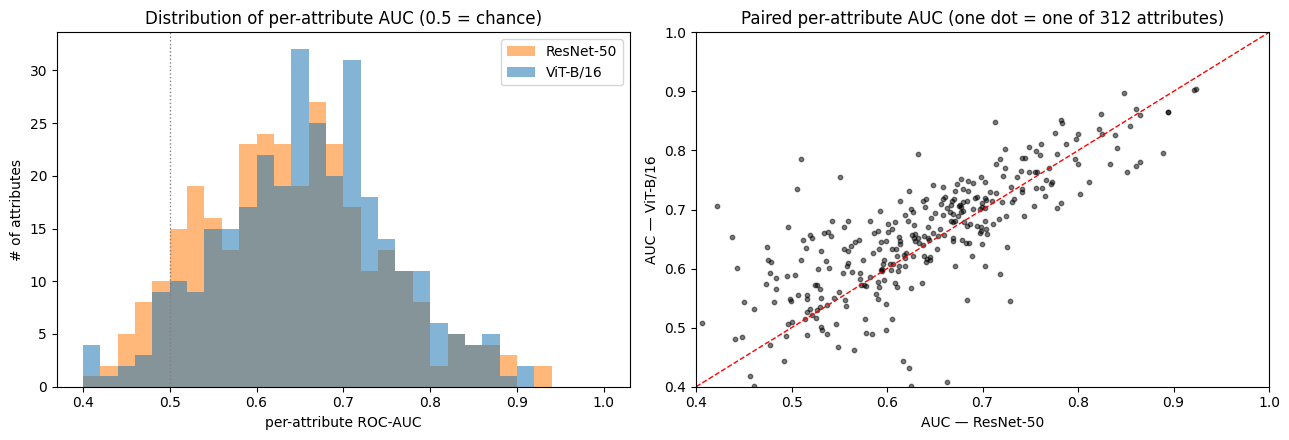

Top-10 attributes where ViT-B/16 BEATS ResNet-50:
  ++0.317  AUC R=0.35  V=0.66  bill_color: rufous
  ++0.283  AUC R=0.42  V=0.71  under_tail_color: purple
  ++0.282  AUC R=0.29  V=0.57  belly_color: purple
  ++0.275  AUC R=0.51  V=0.78  crown_color: rufous
  ++0.271  AUC R=0.36  V=0.64  shape: owl-like
  ++0.229  AUC R=0.51  V=0.73  leg_color: yellow
  ++0.216  AUC R=0.44  V=0.65  forehead_color: purple
  ++0.204  AUC R=0.55  V=0.75  size: very_large_(32_-_72_in)
  ++0.175  AUC R=0.50  V=0.67  leg_color: red
  ++0.161  AUC R=0.63  V=0.79  back_color: olive

Top-10 attributes where ResNet-50 BEATS ViT-B/16:
  -0.255  AUC R=0.66  V=0.41  eye_color: green
  -0.230  AUC R=0.59  V=0.36  throat_color: pink
  -0.224  AUC R=0.63  V=0.40  eye_color: blue
  -0.191  AUC R=0.62  V=0.43  underparts_color: pink
  -0.183  AUC R=0.73  V=0.55  nape_color: rufous
  -0.174  AUC R=0.62  V=0.44  wing_color: pink
  -0.136  AUC R=0.68  V=0.55  breast_color: green
  -0.127  AUC R=0.72  V=0.59  forehead_color

In [4]:
# Section 3 — AUC distributions and per-attribute deltas
def per_attr_auc(pf, l2):
    out = np.full(NUM_L2, np.nan)
    for i in range(NUM_L2):
        y = l2[:, i]
        if y.min() == y.max(): continue
        out[i] = roc_auc_score(y, pf[:, i])
    return out

aucR = per_attr_auc(CACHE["ResNet-50"]["pf"], CACHE["ResNet-50"]["l2"])
aucV = per_attr_auc(CACHE["ViT-B/16"] ["pf"], CACHE["ViT-B/16"] ["l2"])
mask_ok = ~(np.isnan(aucR) | np.isnan(aucV))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(0.4, 1.0, 31)
ax[0].hist(aucR[mask_ok], bins=bins, alpha=0.55, label="ResNet-50",
           color=COLOR["ResNet-50"])
ax[0].hist(aucV[mask_ok], bins=bins, alpha=0.55, label="ViT-B/16",
           color=COLOR["ViT-B/16"])
ax[0].axvline(0.5, color="gray", ls=":", lw=1)
ax[0].set_xlabel("per-attribute ROC-AUC")
ax[0].set_ylabel("# of attributes")
ax[0].set_title("Distribution of per-attribute AUC (0.5 = chance)")
ax[0].legend()

ax[1].scatter(aucR[mask_ok], aucV[mask_ok], s=10, alpha=0.5, color="k")
ax[1].plot([0.4, 1.0], [0.4, 1.0], "r--", lw=1)
ax[1].set_xlabel("AUC — ResNet-50")
ax[1].set_ylabel("AUC — ViT-B/16")
ax[1].set_title("Paired per-attribute AUC (one dot = one of 312 attributes)")
ax[1].set_xlim(0.4, 1.0); ax[1].set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()

delta = aucV - aucR
order = np.argsort(np.where(mask_ok, delta, np.nan))
print("Top-10 attributes where ViT-B/16 BEATS ResNet-50:")
for i in order[::-1][:10]:
    if not mask_ok[i]: continue
    print(f"  +{delta[i]:+.3f}  AUC R={aucR[i]:.2f}  V={aucV[i]:.2f}  "
          f"{clean(attr_names[i], 50)}")
print("\nTop-10 attributes where ResNet-50 BEATS ViT-B/16:")
for i in order[:10]:
    if not mask_ok[i]: continue
    print(f"  {delta[i]:+.3f}  AUC R={aucR[i]:.2f}  V={aucV[i]:.2f}  "
          f"{clean(attr_names[i], 50)}")


---

## Section 4 — Oracle accuracy: how much room does each backbone leave on the table?

**Definition.** *Oracle accuracy* is the top-1 accuracy obtained by **replacing
the model's predicted attribute vector `p_f` with the ground-truth binary
attribute vector `y_l2`**, then feeding `y_l2` (with the same hierarchical
mask using the model's own `p_c`) through the **frozen** classifier. It is
the upper bound that *this* classifier could reach if its concept layer were
perfect.

**Why it matters in a two-model comparison.** Each backbone has its own
classifier on top — i.e., its own learned definition `W ∈ ℝ^{200×312}` of
which attributes mean which species. So oracle accuracy is *not* a property
of the dataset alone; it tells us how well **each model's classifier** would
do if **its own concept layer** were replaced by the truth.

* `Oracle − Actual` is the **headroom** — how much accuracy is being lost
  *because of imperfect concepts*, given everything else stays the same.
* A small headroom means the bottleneck is no longer the concept extractor;
  improving concepts further would barely help.
* A large headroom means concepts *are* the bottleneck, and any concept-level
  intervention (e.g. TTI in the next section) should pay off.

**This cell does:** for each model, computes `accuracy(W·m(y_l2,p_c) + b)`
where `m(·,·)` is the same hierarchical mask used in the forward pass.
It prints two rows — Actual / Oracle / Gap — one per backbone, and overlays
them as a 2-bar grouped bar chart.

**What to look for.** The interpretability story is *not* "the model with
higher oracle is better". It is the **gap**. The model with the smaller gap
is the one whose classifier is best aligned with its own concepts.


model           actual    oracle       gap   naive(GT0/1)
ResNet-50       61.94%    96.91%   +34.97 pp        10.51%
ViT-B/16        86.56%   100.00%   +13.44 pp        11.89%


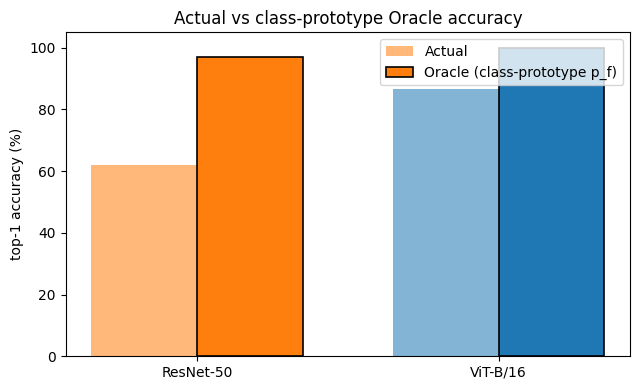

In [5]:
# Section 4 — Oracle accuracy (class-prototype in p_f-space, matches 02/03)
# WHY NOT RAW GT: the classifier was trained on continuous predicted p_f.
# Feeding binary {0,1} GT attributes is out-of-distribution and collapses to
# near-chance (~10%). The honest ceiling is the class-prototype oracle:
#   proto[k] = mean_{i: y_i=k} pf_all[i]
# This stays exactly on the training distribution.
oracle_rows = []
oracle_extra = {}
for name in ["ResNet-50", "ViT-B/16"]:
    C = CACHE[name]
    proto = np.zeros((NUM_CLASSES, NUM_L2), dtype=np.float32)
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for k in range(NUM_CLASSES):
        sel = (C["lbl"] == k)
        counts[k] = int(sel.sum())
        if counts[k] > 0:
            proto[k] = C["pf"][sel].mean(0)
    empty = counts == 0
    if empty.any():
        proto[empty] = C["pf"].mean(0, keepdims=True)
    l2_proto = proto[C["lbl"]]                            # (N, 312)
    logit_oracle = l2_proto @ C["W"].T + C["b"]
    pred_oracle  = logit_oracle.argmax(1)

    # Naive GT oracle (raw 0/1 attrs through the same classifier) — reported
    # for context; will be near chance on H-CBMs trained on continuous p_f.
    if C["l2"].max() > 0:
        logit_naive = C["l2"] @ C["W"].T + C["b"]
        acc_naive   = float((logit_naive.argmax(1) == C["lbl"]).mean())
    else:
        acc_naive = float("nan")

    acc_act = float((C["pred"]   == C["lbl"]).mean())
    acc_orc = float((pred_oracle == C["lbl"]).mean())
    oracle_rows.append((name, acc_act, acc_orc, acc_orc - acc_act))
    oracle_extra[name] = {"l2_proto": l2_proto, "naive": acc_naive}

print(f"{'model':<12} {'actual':>9} {'oracle':>9} {'gap':>9} {'naive(GT0/1)':>14}")
for n, a, o, g in oracle_rows:
    nv = oracle_extra[n]["naive"]
    nv_s = f"{nv*100:>12.2f}%" if not np.isnan(nv) else f"{'nan':>13}"
    print(f"{n:<12} {a*100:>8.2f}% {o*100:>8.2f}% {g*100:>+8.2f} pp {nv_s}")

if oracle_rows:
    names = [r[0] for r in oracle_rows]
    fig, ax = plt.subplots(figsize=(6.5, 4))
    x = np.arange(len(names)); w = 0.35
    ax.bar(x - w/2, [r[1]*100 for r in oracle_rows], w,
           label="Actual", color=[COLOR[n] for n in names], alpha=0.55)
    ax.bar(x + w/2, [r[2]*100 for r in oracle_rows], w,
           label="Oracle (class-prototype p_f)",
           color=[COLOR[n] for n in names], edgecolor="black", linewidth=1.2)
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylabel("top-1 accuracy (%)")
    ax.set_title("Actual vs class-prototype Oracle accuracy")
    ax.legend(); plt.tight_layout(); plt.show()


---

## Section 5 — Test-Time Intervention (TTI) curves overlaid

**Definition.** TTI is the standard CBM diagnostic: pick a subset $S$ of the
312 attributes, and **replace** the model's predicted `p_f[:, S]` with the
ground-truth values `y_l2[:, S]`, then re-run the (frozen) classifier and
re-measure top-1 accuracy. Sweeping $|S|$ from 0 to 312 produces a curve.

**Why it is the central interpretability test for an H-CBM.** TTI is the
*only* test that directly measures **causal control**: when a human edits a
concept, does the prediction change in the way the concept's name promises?
A model whose accuracy barely moves under intervention is a model whose
"concepts" are decorative. A model whose accuracy moves smoothly toward
oracle as more concepts are corrected is a model whose concept layer
genuinely **defines** the prediction.

**This cell does:** for each model, runs the *exact same intervention
schedule* (an order based on per-attribute AUC, ascending — i.e. fix the
worst concepts first, the policy that gives the steepest rise). For each
intervention budget $k \in \{0, 12, 25, 50, 100, 200, 312\}$, it reports
top-1 accuracy and overlays the two curves on one plot, with each model's
oracle accuracy drawn as a horizontal dashed line in its own color.

**What to look for.**

* **Slope at $k=0$** — how much does fixing just the *worst* concepts help?
  Steeper = more reactive classifier.
* **Curvature** — a curve that bends sharply early says most of the headroom
  lives in a few bad concepts; a curve that rises linearly says the bottleneck
  is broadly distributed.
* **Distance to oracle at $k=312$** — both curves *must* hit each model's own
  oracle line at the right edge by definition; if they don't, there is a bug.
* **Crossings.** If the two curves cross, it means one backbone reacts faster
  to early interventions while the other ultimately reaches a higher ceiling —
  this is a non-trivial qualitative difference that a single accuracy number
  cannot capture.


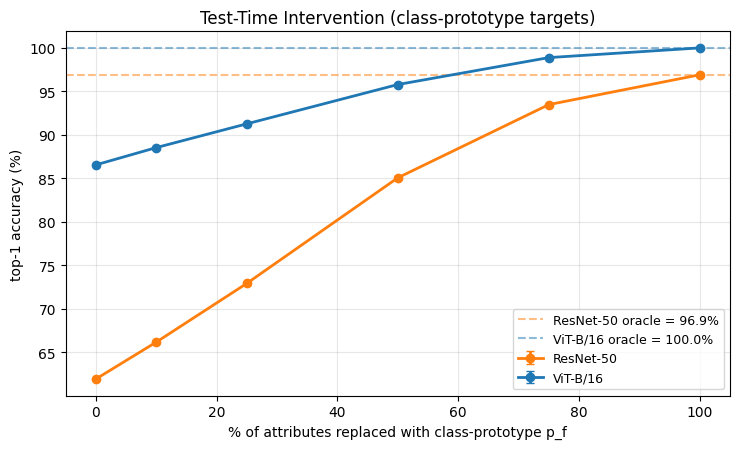

   r% |      ResNet-50 |       ViT-B/16
   0% |   61.94% (±0.00) |   86.56% (±0.00)
  10% |   66.18% (±0.08) |   88.54% (±0.04)
  25% |   72.94% (±0.14) |   91.27% (±0.01)
  50% |   85.07% (±0.16) |   95.79% (±0.07)
  75% |   93.48% (±0.02) |   98.88% (±0.07)
 100% |   96.91% (±0.00) |  100.00% (±0.00)


In [6]:
# Section 5 — TTI: mix predicted p_f with class-prototype p_f (matches 02/03)
import torch as _torch

FRACTIONS = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
N_REPEAT  = 3

def tti_curve_proto(C, l2_proto):
    pf_t       = _torch.tensor(C["pf"],    dtype=_torch.float32)
    proto_t    = _torch.tensor(l2_proto,   dtype=_torch.float32)
    W_t        = _torch.tensor(C["W"],     dtype=_torch.float32)
    b_t        = _torch.tensor(C["b"],     dtype=_torch.float32)
    lbl_t      = _torch.tensor(C["lbl"],   dtype=_torch.long)
    N_total, K = pf_t.shape
    accs, stds = [], []
    with _torch.no_grad():
        for r in FRACTIONS:
            n_replace = int(round(r * K))
            rep = []
            for s in range(N_REPEAT):
                g = _torch.Generator().manual_seed(s)
                if n_replace == 0:
                    mask = _torch.zeros(N_total, K, dtype=_torch.bool)
                elif n_replace == K:
                    mask = _torch.ones(N_total, K, dtype=_torch.bool)
                else:
                    scores = _torch.rand(N_total, K, generator=g)
                    _, top = scores.topk(n_replace, dim=1)
                    mask = _torch.zeros(N_total, K, dtype=_torch.bool)
                    mask.scatter_(1, top, True)
                mixed = _torch.where(mask, proto_t, pf_t)
                logit = mixed @ W_t.T + b_t
                pred  = logit.argmax(1)
                rep.append(float((pred == lbl_t).float().mean()))
            accs.append(float(np.mean(rep)))
            stds.append(float(np.std(rep)))
    return np.array(accs), np.array(stds)

curves = {}
for name in ["ResNet-50", "ViT-B/16"]:
    a, s = tti_curve_proto(CACHE[name], oracle_extra[name]["l2_proto"])
    curves[name] = (a, s)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
xs = [f*100 for f in FRACTIONS]
for name in ["ResNet-50", "ViT-B/16"]:
    a, s = curves[name]
    ax.errorbar(xs, a*100, yerr=s*100, marker="o", capsize=3, lw=2,
                color=COLOR[name], label=name)
for n, _, o, _g in oracle_rows:
    ax.axhline(o*100, ls="--", color=COLOR[n], alpha=0.5,
               label=f"{n} oracle = {o*100:.1f}%")
ax.set_xlabel("% of attributes replaced with class-prototype p_f")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("Test-Time Intervention (class-prototype targets)")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

# --- save figure for Report.tex ---
import os
FIG_DIR = f"{DRIVE_ROOT}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(f"{FIG_DIR}/comparison_tti.png", dpi=150, bbox_inches="tight")
print(f"[fig] saved -> {FIG_DIR}/comparison_tti.png")
plt.tight_layout(); plt.show()

print(f"{'r%':>5} | {'ResNet-50':>14} | {'ViT-B/16':>14}")
for i, r in enumerate(FRACTIONS):
    aR, sR = curves["ResNet-50"][0][i]*100, curves["ResNet-50"][1][i]*100
    aV, sV = curves["ViT-B/16"] [0][i]*100, curves["ViT-B/16"] [1][i]*100
    print(f"{int(r*100):>4}% | {aR:>7.2f}% (±{sR:>4.2f}) | {aV:>7.2f}% (±{sV:>4.2f})")


---

## Section 6 — Per-part causal necessity (hierarchical ablation overlaid)

**Definition.** For each of the 13 body parts $p$, set the part probability
`p_c[:, p]` to **zero** for every image — which by construction zeroes every
descendant attribute through the hierarchical mask `p_f[i] = σ(z_f[i])·p_c[parent(i)]`
— then re-run the classifier and re-measure accuracy. The accuracy drop
$\Delta_p$ is a **causal** measure of how much the model relies on body part $p$
for its predictions.

**Why this is the tightest interpretability test we can run.** Unlike feature
attribution methods (Grad-CAM, integrated gradients, etc.), this ablation is
performed **inside the same forward pass the model actually uses**, on a
quantity (the part probability) that has a name a human can read. There is
no surrogate model, no heuristic.

**Why we run it on both backbones.** This tells us **which body parts each
backbone has learned to depend on** for fine-grained CUB classification.
Two backbones may produce similar overall accuracy but rely on very different
parts — e.g. ViT may distribute reliance across many parts, while ResNet
may concentrate on a few. That is a *real* claim about how each backbone has
internalized the hierarchy.

**This cell does:** runs the ablation independently for each model, on the
shared eval split, and produces two outputs:

1. A **grouped bar chart** with 13 groups (one per part) and 2 bars per
   group (one per model). Y-axis is *accuracy drop in percentage points*.
   Taller bars mean *more necessary* parts.
2. A small printed list of the **3 most-necessary parts per model**, since
   that is the most quotable summary.

**What to look for.**

* **Concentration.** A model whose drops are huge for 2 parts and ~0 for the
  others has a *brittle* explanation — its predictions live or die on 2
  body parts.
* **Ordering changes.** If the top-1 most-necessary part differs between
  the two models, that is the strongest possible evidence that the two
  backbones are doing fine-grained CUB by *different routes*.
* **Total mass.** $\sum_p \Delta_p$ is roughly how much accuracy the model
  attributes to **all** parts together. A higher total means the model has
  successfully grounded its decisions in the part hierarchy; a lower total
  means a non-trivial fraction of its accuracy comes from cross-part
  interactions in the fine head.


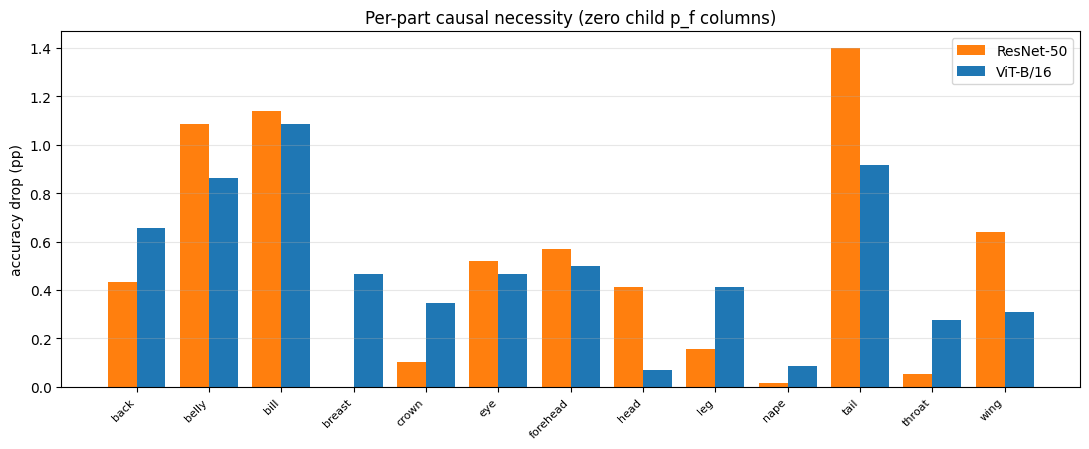

ResNet-50: top-3 most-necessary parts:
   tail                    drop=1.40 pp
   bill                    drop=1.14 pp
   belly                   drop=1.09 pp
   total mass over 13 parts: 6.52 pp

ViT-B/16: top-3 most-necessary parts:
   bill                    drop=1.09 pp
   tail                    drop=0.91 pp
   belly                   drop=0.86 pp
   total mass over 13 parts: 6.45 pp



In [7]:
# Section 6 — per-part causal necessity (zero CHILD p_f columns directly)
# Why not zero p_c[part]: the soft mask is 0.5 + 0.5*p_c[parent], so setting
# p_c[part]=0 only HALVES the children. The honest ablation is to zero the
# child p_f columns themselves -- this removes the branch from W*pf entirely.
def part_drop(C):
    api_np = attr_parent_idx
    base_acc = float((C["pred"] == C["lbl"]).mean())
    pf = C["pf"]
    drops = []
    for p in range(NUM_L1):
        children = np.where(api_np == p)[0]
        if len(children) == 0:
            drops.append(0.0); continue
        pf_mod = pf.copy()
        pf_mod[:, children] = 0.0
        logit = pf_mod @ C["W"].T + C["b"]
        acc   = float((logit.argmax(1) == C["lbl"]).mean())
        drops.append(base_acc - acc)
    return np.array(drops)

dropR = part_drop(CACHE["ResNet-50"])
dropV = part_drop(CACHE["ViT-B/16"])

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(NUM_L1); w = 0.4
ax.bar(x - w/2, dropR*100, w, label="ResNet-50", color=COLOR["ResNet-50"])
ax.bar(x + w/2, dropV*100, w, label="ViT-B/16",  color=COLOR["ViT-B/16"])
ax.set_xticks(x)
ax.set_xticklabels([clean(BODY_PART_NAMES[i], 14) for i in range(NUM_L1)],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("accuracy drop (pp)")
ax.set_title("Per-part causal necessity (zero child p_f columns)")

# --- save figure for Report.tex ---
import os
FIG_DIR = f"{DRIVE_ROOT}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(f"{FIG_DIR}/comparison_partneed.png", dpi=150, bbox_inches="tight")
print(f"[fig] saved -> {FIG_DIR}/comparison_partneed.png")
ax.legend(); ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

for name, d in [("ResNet-50", dropR), ("ViT-B/16", dropV)]:
    top = np.argsort(d)[::-1][:3]
    print(f"{name}: top-3 most-necessary parts:")
    for p in top:
        print(f"   {clean(BODY_PART_NAMES[p],22):<22}  drop={d[p]*100:.2f} pp")
    print(f"   total mass over 13 parts: {d.sum()*100:.2f} pp\n")


---

## Section 7 — Calibration of attribute probabilities (reliability diagrams)

**Why calibration matters specifically for an H-CBM.** When a CBM exposes a
probability `p_f[i] = 0.7` to a user, the user is being told *"there's a 70 %
chance that attribute $i$ is present"*. If the model is well-calibrated, that
statement is true: among all `(image, attribute)` pairs where the model
outputs ~0.7, about 70 % really do have the attribute. **Without calibration,
the probabilities are not interpretable as probabilities** — they are just
ranks.

For TTI in particular this matters. A TTI user must decide whether to trust
the model's prediction or override it; that decision uses `p_f` as a
probability. Bad calibration → bad TTI ergonomics, even when AUC is fine.

**This cell does:** pools all `(p_f[n,i], y_l2[n,i])` pairs across the eval
split and the 312 attributes, bins them by predicted probability into 15
equal-width bins, and plots **two reliability curves** (mean empirical
positive rate per bin vs bin midpoint) side-by-side, with the diagonal
"perfectly calibrated" line drawn. ECE is reprinted.

**What to look for.**

* A curve **above** the diagonal in the lower bins means the model is
  **under-confident** — when it says 0.2 it's actually right ~0.4 of the time.
* A curve **below** the diagonal in the upper bins means the model is
  **over-confident** — when it says 0.9 it's right less than 90 % of the
  time. Over-confidence is the more dangerous failure mode for an
  interpretability tool.
* **Bin counts** are also drawn (transparent gray bars on the secondary axis)
  so the reader can ignore bins with too few points to be meaningful.


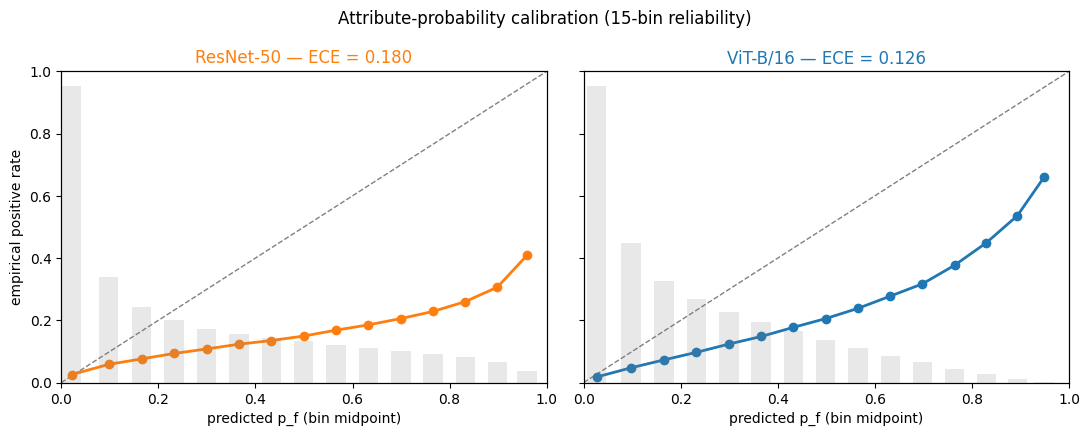

In [8]:
# Section 7 — reliability diagrams side-by-side
def reliability(p, y, bins=15):
    p = p.ravel(); y = y.ravel()
    edges = np.linspace(0, 1, bins+1)
    mids, emp, cnt = [], [], []
    for i in range(bins):
        if i < bins-1: m = (p >= edges[i]) & (p <  edges[i+1])
        else:          m = (p >= edges[i]) & (p <= edges[i+1])
        if m.sum() == 0: continue
        mids.append(p[m].mean())
        emp.append(y[m].mean())
        cnt.append(m.sum())
    return np.array(mids), np.array(emp), np.array(cnt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, name in zip(axes, ["ResNet-50", "ViT-B/16"]):
    C = CACHE[name]
    if C["l2"].max() == 0:
        ax.text(0.5, 0.5, "no GT attrs", ha="center", va="center"); continue
    mids, emp, cnt = reliability(C["pf"], C["l2"], 15)
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.plot(mids, emp, marker="o", color=COLOR[name], lw=2)
    ax2 = ax.twinx()
    ax2.bar(mids, cnt, width=0.04, alpha=0.18, color="gray")
    ax2.set_yticks([])
    e = _ece(C["pf"], C["l2"], 15)
    ax.set_title(f"{name} — ECE = {e:.3f}", color=COLOR[name])
    ax.set_xlabel("predicted p_f (bin midpoint)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[0].set_ylabel("empirical positive rate")
plt.suptitle("Attribute-probability calibration (15-bin reliability)")
plt.tight_layout(); plt.show()


---

## Section 8 — Classifier weight structure: are the species "definitions" comparable?

**Reminder.** Both models have the same final layer `Linear(312 → 200)`,
i.e. an *interpretable definition* of every species as a real-valued vector
over the 312 attributes. We can compare these two `W` matrices directly.

**This cell measures three properties of `W` for each model:**

1. **Sparsity proxy** — the L1/L2 ratio per row, $\|W_k\|_1 / \|W_k\|_2$,
   averaged over the 200 species. A higher value means each species "uses"
   more attributes; a lower value means the definition concentrates on a
   small subset (more concise explanations).
2. **Top-$k$ mass** — for each species, the fraction of $\sum_i |W_{k,i}|$
   captured by the top-$k$ largest attributes. We average across species
   and plot vs $k$. The curve that rises faster has *more concise* learned
   class definitions.
3. **Part-mass concentration** — for each species, $\sum_p \big(\sum_{i:\text{parent}(i)=p}|W_{k,i}|\big)^2 / \big(\sum_i |W_{k,i}|\big)^2$
   (a Herfindahl-style index over the 13 body parts). Higher = each species
   is defined using attributes from a few parts; lower = each species is
   defined using attributes spread evenly across all parts.

**Why these three matter for interpretability.** Concise, part-localized
species definitions are what a human ornithologist would write. So a model
whose `W` is sparser **and** more part-localized has produced a more
human-aligned classifier on top of its concept layer. Two backbones can lead
to very different `W` structures even when their concept layers look similar
on AUC.

**Output.** A side-by-side bar chart for the sparsity and part-Herfindahl
numbers, plus the top-$k$ mass curve overlaid. Three single numbers per
backbone. We also print a short top-3 contributor list for one example
species (American Goldfinch, class 9) so the reader can see qualitatively
what each backbone's $W$ looks like.


metric                        ResNet-50   ViT-B/16
----------------------------------------------------
sparsity (L1/L2 mean)            14.497     14.724
part Herfindahl                   0.093      0.092
top-1 mass                        0.011      0.010
top-5 mass                        0.048      0.046
top-20 mass                       0.166      0.158
top-50 mass                       0.353      0.339


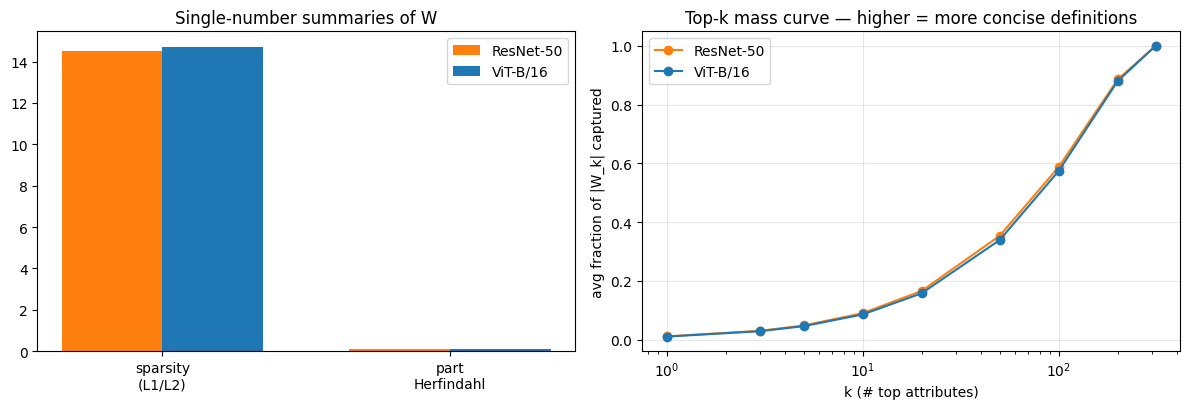


Example: top-3 attributes for class 'Red winged Blackbird'
  ResNet-50  upperparts_color: brown (-0.40) | upperparts_color: purple (-0.38) | bill_shape: curved_(up_or_down) (-0.38)
  ViT-B/16   upperparts_color: blue (-0.45) | nape_color: red (-0.44) | wing_shape: long-wings (-0.41)


In [9]:
# Section 8 — classifier weight structure comparison
def weight_stats(W):
    Wabs = np.abs(W)
    l1   = Wabs.sum(1); l2 = np.sqrt((W**2).sum(1)) + 1e-12
    sparsity_ratio = float((l1 / l2).mean())
    K_grid = [1, 3, 5, 10, 20, 50, 100, 200, 312]
    sorted_desc = -np.sort(-Wabs, axis=1)
    cumsum = sorted_desc.cumsum(1)
    total = Wabs.sum(1, keepdims=True) + 1e-12
    mass_curve = (cumsum / total).mean(0)
    top_mass = {k: float(mass_curve[k-1]) for k in K_grid}
    H = []
    for k in range(W.shape[0]):
        per_part = np.zeros(NUM_L1)
        for p in range(NUM_L1):
            sel = np.where(attr_parent_idx == p)[0]
            per_part[p] = Wabs[k, sel].sum()
        s = per_part.sum() + 1e-12
        H.append(((per_part / s)**2).sum())
    herf = float(np.mean(H))
    return sparsity_ratio, top_mass, herf, mass_curve, K_grid

statsR = weight_stats(CACHE["ResNet-50"]["W"])
statsV = weight_stats(CACHE["ViT-B/16"] ["W"])

print(f"{'metric':<28} {'ResNet-50':>10} {'ViT-B/16':>10}")
print("-"*52)
print(f"{'sparsity (L1/L2 mean)':<28} {statsR[0]:>10.3f} {statsV[0]:>10.3f}")
print(f"{'part Herfindahl':<28} {statsR[2]:>10.3f} {statsV[2]:>10.3f}")
for k in [1, 5, 20, 50]:
    print(f"{f'top-{k} mass':<28} {statsR[1][k]:>10.3f} {statsV[1][k]:>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
labels = ["sparsity\n(L1/L2)", "part\nHerfindahl"]
xs = np.arange(2); w = 0.35
ax.bar(xs - w/2, [statsR[0], statsR[2]], w,
       color=COLOR["ResNet-50"], label="ResNet-50")
ax.bar(xs + w/2, [statsV[0], statsV[2]], w,
       color=COLOR["ViT-B/16"], label="ViT-B/16")
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_title("Single-number summaries of W"); ax.legend()

ax = axes[1]
ax.plot(statsR[4], statsR[3][np.array(statsR[4])-1], marker="o",
        color=COLOR["ResNet-50"], label="ResNet-50")
ax.plot(statsV[4], statsV[3][np.array(statsV[4])-1], marker="o",
        color=COLOR["ViT-B/16"], label="ViT-B/16")
ax.set_xscale("log"); ax.set_xlabel("k (# top attributes)")
ax.set_ylabel("avg fraction of |W_k| captured")
ax.set_title("Top-k mass curve — higher = more concise definitions")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

SPECIES_IDX = 9 if NUM_CLASSES > 9 else 0
print(f"\nExample: top-3 attributes for class '{class_names[SPECIES_IDX]}'")
for name in ["ResNet-50", "ViT-B/16"]:
    Wk = CACHE[name]["W"][SPECIES_IDX]
    top = np.argsort(np.abs(Wk))[::-1][:3]
    txts = [f"{clean(attr_names[i], 32)} ({Wk[i]:+.2f})" for i in top]
    print(f"  {name:<10} {' | '.join(txts)}")


---

## Section 9 — Where do the two backbones **disagree**?

**Motivation.** Two models with identical accuracy can still disagree on
half the images — they just compensate for each other. Studying *which*
images they disagree on (and *which* species they disagree on) is the most
direct way to see what each backbone uniquely contributes.

**This cell does:**

1. Builds the **2 × 2 agreement matrix** over the eval split:
   - both right
   - only ResNet right
   - only ViT right
   - both wrong
2. For the "only-X-right" subsets, prints how many images, and what fraction
   of total errors of the *other* model could be flipped if we knew when to
   trust X (the **complementarity ceiling**).
3. Shows a **per-class** view: for each of the 200 species, how many images
   ResNet got right that ViT did not, and vice versa. We sort and print the
   top-15 classes where ViT uniquely shines, and the top-15 where ResNet
   uniquely shines. These are usually species-level claims worth reading.
4. Computes the **simple oracle ensemble** (pick whichever model is right;
   tie-break by softmax confidence). Its accuracy is an upper bound on what
   you could get by selecting between the two — and a useful sanity check
   on whether the disagreements are signal-rich or noise-rich.

**What to look for.**

* If the **both-right** cell dominates (>90 % of total accuracy), the two
  models agree most of the time and the rest of the table is tail noise.
* If the **only-X-right** cells are large and roughly symmetric, the
  backbones are genuinely complementary and the oracle ensemble will jump
  several points above either.
* Per-class lopsidedness (ViT uniquely correct on, e.g., warblers and
  ResNet uniquely correct on owls) reveals **systematic** strengths,
  not random differences.


Agreement matrix on N=5794 eval images:
  both correct        :  3435  (59.29%)
  only ResNet correct :   154  ( 2.66%)
  only ViT    correct :  1580  (27.27%)
  both wrong          :   625  (10.79%)

Prediction agreement: 63.39%   Cohen's kappa = 0.632
Oracle-selection ensemble upper-bound: 89.21%
Confidence-tie-break ensemble:         83.95%

Top-15 species where ViT-B/16 is uniquely correct (ViT - ResNet):
  +23   V=23  R= 0   Great Crested Flycatcher
  +19   V=19  R= 0   Prairie Warbler
  +19   V=19  R= 0   Yellow breasted Chat
  +18   V=18  R= 0   Yellow throated Vireo
  +18   V=18  R= 0   Nelson Sharp tailed Sparrow
  +17   V=17  R= 0   American Redstart
  +17   V=18  R= 1   Orange crowned Warbler
  +17   V=18  R= 1   Northern Fulmar
  +16   V=16  R= 0   Brewer Sparrow
  +16   V=16  R= 0   Grasshopper Sparrow
  +15   V=15  R= 0   White necked Raven
  +15   V=15  R= 0   Myrtle Warbler
  +15   V=15  R= 0   Mourning Warbler
  +15   V=15  R= 0   Ruby throated Hummingbird
  +15   V=17

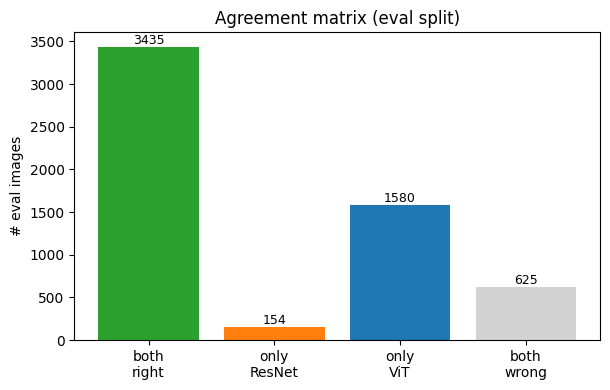

In [10]:
# Section 9 — disagreement analysis
predR = CACHE["ResNet-50"]["pred"]
predV = CACHE["ViT-B/16"] ["pred"]
lbl   = CACHE["ResNet-50"]["lbl"]
N     = len(lbl)
okR, okV = (predR == lbl), (predV == lbl)

bothR  = (okR &  okV).sum()
onlyR  = (okR & ~okV).sum()
onlyV  = (~okR &  okV).sum()
bothW  = (~okR & ~okV).sum()

print(f"Agreement matrix on N={N} eval images:")
print(f"  both correct        : {bothR:>5d}  ({bothR/N*100:5.2f}%)")
print(f"  only ResNet correct : {onlyR:>5d}  ({onlyR/N*100:5.2f}%)")
print(f"  only ViT    correct : {onlyV:>5d}  ({onlyV/N*100:5.2f}%)")
print(f"  both wrong          : {bothW:>5d}  ({bothW/N*100:5.2f}%)")

po = (predR == predV).mean()
fr = np.bincount(predR, minlength=NUM_CLASSES) / N
fv = np.bincount(predV, minlength=NUM_CLASSES) / N
pe = (fr * fv).sum()
kappa = (po - pe) / (1 - pe + 1e-12)
print(f"\nPrediction agreement: {po*100:.2f}%   Cohen's kappa = {kappa:.3f}")

ens_acc = (okR | okV).mean()
print(f"Oracle-selection ensemble upper-bound: {ens_acc*100:.2f}%")

def softmax(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)
sR = softmax(CACHE["ResNet-50"]["logit"]).max(1)
sV = softmax(CACHE["ViT-B/16"] ["logit"]).max(1)
pick = np.where(sR >= sV, predR, predV)
print(f"Confidence-tie-break ensemble:         {(pick==lbl).mean()*100:.2f}%")

class_only_R = np.zeros(NUM_CLASSES, int)
class_only_V = np.zeros(NUM_CLASSES, int)
for k in range(NUM_CLASSES):
    m = (lbl == k)
    class_only_R[k] = (m & okR & ~okV).sum()
    class_only_V[k] = (m & okV & ~okR).sum()

ord_v = np.argsort(class_only_V - class_only_R)[::-1][:15]
ord_r = np.argsort(class_only_R - class_only_V)[::-1][:15]
print("\nTop-15 species where ViT-B/16 is uniquely correct (ViT - ResNet):")
for k in ord_v:
    print(f"  +{class_only_V[k]-class_only_R[k]:>2d}   "
          f"V={class_only_V[k]:>2d}  R={class_only_R[k]:>2d}   "
          f"{class_names[k]}")
print("\nTop-15 species where ResNet-50 is uniquely correct (ResNet - ViT):")
for k in ord_r:
    print(f"  +{class_only_R[k]-class_only_V[k]:>2d}   "
          f"R={class_only_R[k]:>2d}  V={class_only_V[k]:>2d}   "
          f"{class_names[k]}")

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.bar(["both\nright", "only\nResNet", "only\nViT", "both\nwrong"],
       [bothR, onlyR, onlyV, bothW],
       color=["tab:green", COLOR["ResNet-50"], COLOR["ViT-B/16"], "lightgray"])
for i, v in enumerate([bothR, onlyR, onlyV, bothW]):
    ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# eval images")

# --- save figure for Report.tex ---
import os
FIG_DIR = f"{DRIVE_ROOT}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(f"{FIG_DIR}/comparison_agreement.png", dpi=150, bbox_inches="tight")
print(f"[fig] saved -> {FIG_DIR}/comparison_agreement.png")
ax.set_title("Agreement matrix (eval split)"); plt.tight_layout(); plt.show()


---

## Section 10 — Verdict: putting all comparisons in one table

The cell below assembles **every single number** computed above into one row
per backbone, so the reader can scan the comparison without scrolling. We
also print, per axis, an arrow indicating which backbone wins on that axis
(↑ = better; for ECE / NLL / "gap to oracle" / W-sparsity, *lower* is
better, and the arrow is flipped accordingly).

**How to use this table.** It is the executive summary of the notebook. It
is **not** a proxy for reading the individual sections — the *shape* of the
distributions and the *names* of attributes/species in the deltas are where
the actual scientific claims live. But for citing one backbone over another
in a write-up, this is the table to use.


In [11]:
# Section 10 — final summary table
metrics = {}
for n in ["ResNet-50", "ViT-B/16"]:
    C = CACHE[n]
    acc  = (C["pred"] == C["lbl"]).mean()
    nll  = _nll(C["logit"], C["lbl"])
    has_l2 = C["l2"].max() > 0
    if has_l2:
        mauc, _ = _mean_auc(C["pf"], C["l2"])
        ece     = _ece(C["pf"], C["l2"], 15)
        brier   = float(((C["pf"] - C["l2"])**2).mean())
    else:
        mauc = ece = brier = float("nan")
    metrics[n] = dict(acc=acc, nll=nll, mAUC=mauc, ECE=ece, Brier=brier)

for n, _, o, g in oracle_rows:
    metrics[n]["oracle"] = o
    metrics[n]["gap"]    = g

stats = {"ResNet-50": statsR, "ViT-B/16": statsV}
for n in metrics:
    metrics[n]["sparsity"] = stats[n][0]
    metrics[n]["partHerf"] = stats[n][2]

drops = {"ResNet-50": dropR, "ViT-B/16": dropV}
for n in metrics:
    metrics[n]["partMass"] = drops[n].sum()
    metrics[n]["partTop1"] = drops[n].max()

axes_ = [
    ("top-1 acc (%)",       "acc",      "high", lambda v: f"{v*100:.2f}"),
    ("NLL",                 "nll",      "low",  lambda v: f"{v:.3f}"),
    ("mean attr-AUC",       "mAUC",     "high", lambda v: f"{v:.3f}"),
    ("attr ECE",            "ECE",      "low",  lambda v: f"{v:.3f}"),
    ("attr Brier",          "Brier",    "low",  lambda v: f"{v:.4f}"),
    ("oracle acc (%)",      "oracle",   "high", lambda v: f"{v*100:.2f}"),
    ("gap (oracle-actual)", "gap",      "low",  lambda v: f"{v*100:+.2f}"),
    ("W sparsity (L1/L2)",  "sparsity", "low",  lambda v: f"{v:.2f}"),
    ("W part Herfindahl",   "partHerf", "high", lambda v: f"{v:.3f}"),
    ("\u03a3 part drops (pp)",   "partMass", "high", lambda v: f"{v*100:.2f}"),
    ("max part drop (pp)",  "partTop1", "high", lambda v: f"{v*100:.2f}"),
]

print(f"{'axis':<22} {'ResNet-50':>12} {'ViT-B/16':>12}   winner")
print("-"*64)
score = {"ResNet-50": 0, "ViT-B/16": 0}
for label, key, dirn, fmt in axes_:
    a = metrics["ResNet-50"].get(key, float("nan"))
    b = metrics["ViT-B/16"] .get(key, float("nan"))
    if np.isnan(a) or np.isnan(b):
        win = "\u2014"
    else:
        if dirn == "high": win = "ResNet-50" if a > b else ("ViT-B/16" if b > a else "tie")
        else:              win = "ResNet-50" if a < b else ("ViT-B/16" if b < a else "tie")
        if win in score: score[win] += 1
    print(f"{label:<22} {fmt(a):>12} {fmt(b):>12}   {win}")
print("-"*64)
print(f"axes-won score    R={score['ResNet-50']}   V={score['ViT-B/16']}")


axis                      ResNet-50     ViT-B/16   winner
----------------------------------------------------------------
top-1 acc (%)                 61.94        86.56   ViT-B/16
NLL                           1.459        0.697   ViT-B/16
mean attr-AUC                 0.636        0.656   ViT-B/16
attr ECE                      0.180        0.126   ViT-B/16
attr Brier                   0.1537       0.1117   ViT-B/16
oracle acc (%)                96.91       100.00   ViT-B/16
gap (oracle-actual)          +34.97       +13.44   ViT-B/16
W sparsity (L1/L2)            14.50        14.72   ResNet-50
W part Herfindahl             0.093        0.092   ResNet-50
Σ part drops (pp)              6.52         6.45   ResNet-50
max part drop (pp)             1.40         1.09   ResNet-50
----------------------------------------------------------------
axes-won score    R=4   V=7


---

---

## Section 11 — Feature-difficulty tiers: which concepts are easy, hard, or out of reach?

**Motivation.** Sections 3 and 4 told us *who wins* on each attribute, but
not *how hard each attribute is*. A CBM that gets bill-shape right and eye-
colour wrong is making a very different statement than one that gets both
right or both wrong. We therefore bucket the 312 attributes into five tiers
based on the AUC pair `(AUC_ResNet[i], AUC_ViT[i])`:

| Tier | Rule | What it means |
|---|---|---|
| **Easy — both detect** | `min(AUC_R, AUC_V) ≥ 0.75` | Concept is learnable from either backbone; the visual signal is strong enough that a CNN pooled vector captures it. |
| **Hard — only ViT** | `AUC_V ≥ 0.70 ∧ AUC_R < 0.65` | Concept needs the global attention pooling of ViT; ResNet's spatial bottleneck loses it. |
| **Hard — only ResNet** | `AUC_R ≥ 0.70 ∧ AUC_V < 0.65` | Concept that ResNet's local texture filters pick up but ViT's patch tokens blur. |
| **Very hard — neither** | `max(AUC_R, AUC_V) < 0.60` | Out of reach for both backbones — likely under-represented, semantically ambiguous, or visually subtle (e.g. rare colour on a small body part). |
| **Medium** | everything else | Both moderate; not a clean win for either side. |

**This cell does (4 outputs):**

1. **Tier counts** — how many of the 312 attributes fall in each tier.
2. **Coloured scatter** of `(AUC_R, AUC_V)` with tier-coloured points and the
   tier boundaries drawn — a single image you can put in the report.
3. **Per-tier examples** — 6 named attributes per tier so the reader can
   read what *kind* of concept lives in each bucket.
4. **Per-part breakdown** — for each of the 13 body parts, how many of its
   child attributes fall in each tier. Reveals which parts have systematic
   "very-hard" concepts — and therefore which parts are the next target for
   improving the bottleneck.

**What to look for.**

* If the **Easy** bucket dominates, then the bottleneck design is well-matched
  to the CUB attribute vocabulary and most of the remaining error is in the
  classifier head (consistent with the oracle gap of § 4).
* The **only-ViT** bucket gives a concrete, *named* list of concepts that
  justify choosing a ViT backbone: e.g. shape/size descriptors that need
  long-range patch interaction.
* The **very-hard** bucket is the most actionable for future work: it lists
  concepts where neither backbone is enough, so they are the right targets
  for architectural or data-side intervention.



Tiering 312/312 attributes (rest had constant GT)
tier                    count    share
----------------------------------------
Easy (both)                34    10.9%
Hard (only ViT)            12     3.8%
Hard (only ResNet)          4     1.3%
Very hard (neither)        72    23.1%
Medium                    190    60.9%


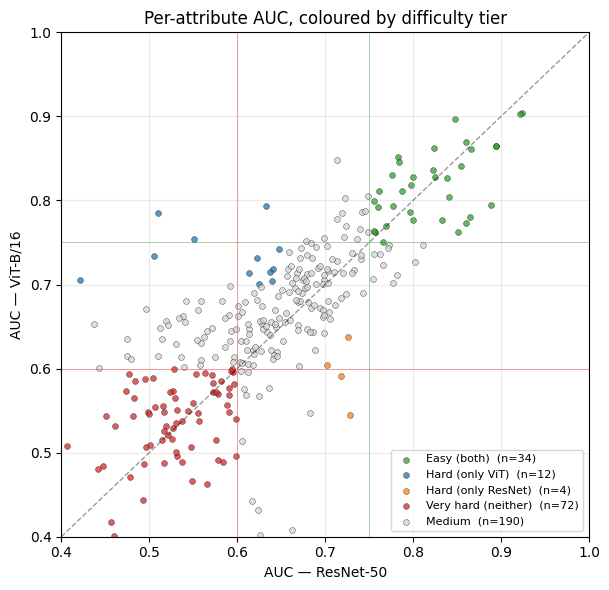


Easy (both) -- examples:
  AUC R=0.92  V=0.90   underparts_color: yellow
  AUC R=0.92  V=0.90   breast_color: yellow
  AUC R=0.89  V=0.87   belly_color: yellow
  AUC R=0.89  V=0.86   crown_color: blue
  AUC R=0.87  V=0.86   forehead_color: blue
  AUC R=0.86  V=0.87   forehead_color: yellow

Hard (only ViT) -- examples:
  AUC R=0.42  V=0.71   under_tail_color: purple
  AUC R=0.51  V=0.78   crown_color: rufous
  AUC R=0.51  V=0.73   leg_color: yellow
  AUC R=0.55  V=0.75   size: very_large_(32_-_72_in)
  AUC R=0.63  V=0.79   back_color: olive
  AUC R=0.62  V=0.73   breast_color: olive

Hard (only ResNet) -- examples:
  AUC R=0.73  V=0.55   nape_color: rufous
  AUC R=0.72  V=0.59   forehead_color: rufous
  AUC R=0.70  V=0.60   breast_color: rufous
  AUC R=0.73  V=0.64   bill_color: red

Very hard (neither) -- examples:
  AUC R=0.46  V=0.42   eye_color: grey
  AUC R=0.46  V=0.40   back_color: pink
  AUC R=0.48  V=0.47   primary_color: purple
  AUC R=0.44  V=0.48   upper_tail_color: rufous

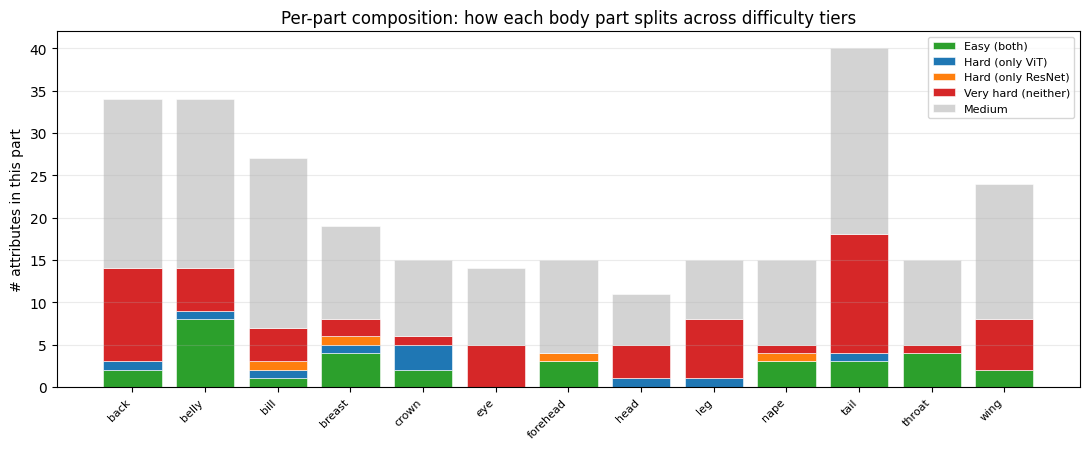


Parts ranked by # of 'very hard' attributes (next-to-fix targets):
  tail                    very-hard=14   easy= 3
  back                    very-hard=11   easy= 2
  leg                     very-hard= 7   easy= 0
  wing                    very-hard= 6   easy= 2
  eye                     very-hard= 5   easy= 0


In [12]:
# Section 11 — feature-difficulty tiers (Easy / only-ViT / only-ResNet /
# Very-hard / Medium) from the per-attribute AUC pair (AUC_R, AUC_V).
# Reuses `aucR`, `aucV`, `mask_ok`, `attr_parent_idx`, `BODY_PART_NAMES`,
# `attr_names`, `clean`, `COLOR` and `NUM_L1` from earlier cells.
TH_EASY = 0.75   # both must clear this to count as "easy"
TH_HARD_HI = 0.70  # the winning backbone needs at least this AUC
TH_HARD_LO = 0.65  # the losing backbone must be below this AUC
TH_VHARD = 0.60  # max of both below this -> very hard

def tier_of(r, v):
    if np.isnan(r) or np.isnan(v):           return "n/a"
    if min(r, v) >= TH_EASY:                  return "Easy (both)"
    if v >= TH_HARD_HI and r < TH_HARD_LO:    return "Hard (only ViT)"
    if r >= TH_HARD_HI and v < TH_HARD_LO:    return "Hard (only ResNet)"
    if max(r, v) < TH_VHARD:                  return "Very hard (neither)"
    return "Medium"

TIER_ORDER = ["Easy (both)", "Hard (only ViT)", "Hard (only ResNet)",
              "Very hard (neither)", "Medium"]
TIER_COLOR = {
    "Easy (both)":          "tab:green",
    "Hard (only ViT)":      COLOR["ViT-B/16"],
    "Hard (only ResNet)":   COLOR["ResNet-50"],
    "Very hard (neither)":  "tab:red",
    "Medium":               "lightgray",
}

tiers = np.array([tier_of(aucR[i], aucV[i]) for i in range(NUM_L2)])

# --- (1) counts -----------------------------------------------------------
n_evaluable = int(mask_ok.sum())
print(f"Tiering {n_evaluable}/{NUM_L2} attributes (rest had constant GT)")
print(f"{'tier':<22} {'count':>6}  {'share':>7}")
print("-" * 40)
for t in TIER_ORDER:
    n = int((tiers == t).sum())
    pct = 100.0 * n / max(n_evaluable, 1)
    print(f"{t:<22} {n:>6}  {pct:>6.1f}%")

# --- (2) scatter coloured by tier ----------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 6.0))
for t in TIER_ORDER:
    sel = (tiers == t) & mask_ok
    if not sel.any(): continue
    ax.scatter(aucR[sel], aucV[sel], s=18, alpha=0.75,
               color=TIER_COLOR[t], edgecolor="k", linewidth=0.3,
               label=f"{t}  (n={int(sel.sum())})")
ax.plot([0.4, 1.0], [0.4, 1.0], "k--", lw=1, alpha=0.4)
ax.axhline(TH_EASY, color="green", lw=0.6, alpha=0.4)
ax.axvline(TH_EASY, color="green", lw=0.6, alpha=0.4)
ax.axhline(TH_VHARD, color="red",   lw=0.6, alpha=0.4)
ax.axvline(TH_VHARD, color="red",   lw=0.6, alpha=0.4)
ax.set_xlim(0.4, 1.0); ax.set_ylim(0.4, 1.0)
ax.set_xlabel("AUC — ResNet-50"); ax.set_ylabel("AUC — ViT-B/16")
ax.set_title("Per-attribute AUC, coloured by difficulty tier")
ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

# --- (3) examples per tier (sorted by min/max AUC for stability) ---------
def _examples(t, k=6):
    idx = np.where((tiers == t) & mask_ok)[0]
    if t == "Easy (both)":
        idx = idx[np.argsort(-np.minimum(aucR[idx], aucV[idx]))]
    elif t == "Hard (only ViT)":
        idx = idx[np.argsort(-(aucV[idx] - aucR[idx]))]
    elif t == "Hard (only ResNet)":
        idx = idx[np.argsort(-(aucR[idx] - aucV[idx]))]
    elif t == "Very hard (neither)":
        idx = idx[np.argsort(np.maximum(aucR[idx], aucV[idx]))]
    else:
        idx = idx[np.argsort(-((aucR[idx] + aucV[idx]) / 2.0))]
    return idx[:k]

for t in TIER_ORDER:
    ex = _examples(t, 6)
    if len(ex) == 0:
        print(f"\n{t}: (empty)")
        continue
    print(f"\n{t} -- examples:")
    for i in ex:
        print(f"  AUC R={aucR[i]:.2f}  V={aucV[i]:.2f}   {clean(attr_names[i], 56)}")

# --- (4) per-part tier composition ---------------------------------------
counts = np.zeros((NUM_L1, len(TIER_ORDER)), dtype=int)
for i in range(NUM_L2):
    p = int(attr_parent_idx[i])
    if p < 0 or not mask_ok[i]: continue
    counts[p, TIER_ORDER.index(tiers[i])] += 1

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(NUM_L1)
bottom = np.zeros(NUM_L1)
for k, t in enumerate(TIER_ORDER):
    ax.bar(x, counts[:, k], bottom=bottom, label=t, color=TIER_COLOR[t],
           edgecolor="white", linewidth=0.4)
    bottom += counts[:, k]
ax.set_xticks(x)
ax.set_xticklabels([clean(BODY_PART_NAMES[i], 14) for i in range(NUM_L1)],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("# attributes in this part")
ax.set_title("Per-part composition: how each body part splits across difficulty tiers")
ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

# print parts with the most "very hard" concepts -- the next targets to fix
vh_idx = TIER_ORDER.index("Very hard (neither)")
order = np.argsort(-counts[:, vh_idx])
print("\nParts ranked by # of 'very hard' attributes (next-to-fix targets):")
for p in order[:5]:
    if counts[p, vh_idx] == 0: break
    print(f"  {clean(BODY_PART_NAMES[p], 22):<22}  "
          f"very-hard={counts[p, vh_idx]:>2}   "
          f"easy={counts[p, 0]:>2}")


---

## How to read this comparison in a write-up

* **Use § 2 (headline)** for the one-line accuracy / NLL / AUC summary.
* **Use § 3 (AUC distribution)** if you want to defend a claim about *concept
  fidelity* -- including the per-attribute deltas, which name *which*
  attributes each backbone is better at.
* **Use § 4 (oracle gap)** to argue about whether the bottleneck is the
  concepts or the classifier.
* **Use § 5 (TTI)** for the strongest causal-control claim -- this is the
  number that distinguishes a real CBM from a decorative one.
* **Use § 6 (per-part necessity)** to make a *what is the model actually
  using?* claim, with named body parts.
* **Use § 7 (calibration)** to defend whether the probabilities can be
  trusted at face value (matters for any human-in-the-loop deployment).
* **Use § 8 (W structure)** to say whether the species *definitions* are
  concise and part-localized.
* **Use § 9 (disagreement)** to argue for *complementarity* -- i.e. that the
  two backbones are not redundant, and an ensemble has real headroom.
* **Use § 10 (verdict table)** as the single artifact to cite when
  summarizing the comparison.
* **Use § 11 (feature-difficulty tiers)** to point at *named* concepts that
  are easy / only-ViT / only-ResNet / very-hard -- this is the tier that
  motivates choosing a backbone, and lists the next-to-fix targets.
